In [3]:
cd ..

/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN


/Users/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
!pwd

/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN


In [5]:
import os 
import sys

sys.path.append(os.path.dirname(os.getcwd()))

from env_constants import PYGARMENT_ROOT

sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg

from sewing_pattern import (
    Stitch, StitchDict, SVGPanel, SewingPattern,
    # ParameterizedSeamLine, ParameterizedEdgeLine,
    # UnconstrainedFewViewLabel
)

In [14]:
import os
from glob import glob
import pickle

garment_path_list = sorted(glob(os.path.join("SAMPLE_DATA", "0814", "*")))

sample_ann_path = glob(os.path.join(garment_path_list[0], "*.pkl"))[0]

sample_ann = pickle.load(open(sample_ann_path, "rb"))

In [ ]:
from glob import glob
from tqdm import tqdm
from copy import deepcopy
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import cv2
import pickle
from PIL import Image


import random
from typing import List, Dict
from dataclasses import dataclass


@dataclass
class SeamLine :
    segment_idx_arr_list : List[np.ndarray]
    segment_pos_arr_list : List[np.ndarray]
    segment_edge_len_arr_list : List[np.ndarray]
    segment_t_arr_list : List[np.ndarray]
    segment_u_arr_list : List[np.ndarray]
    segment_v_arr_list : List[np.ndarray]
    
    def translate(self, dx : float, dy : float) :
        for segment_pos_arr in self.segment_pos_arr_list :
            segment_pos_arr[:, 0] += dx
            segment_pos_arr[:, 1] += dy


class SingleViewLabel :
    """
    class for single view image plus seam line annotation
    """
    def __init__(self,
        img : np.ndarray,
        seam_annotation : Dict[str, Dict[int, SeamLine]],
    ) :
        self.img = img
        self.seam_annotation = seam_annotation
        
    @staticmethod
    def from_file_path(
        img_path : str,
        seam_annotation_path : str,
    ) :
        img = cv2.imread(
            img_path,
            cv2.IMREAD_UNCHANGED
        )
        seam_annotation_raw = pickle.load(open(seam_annotation_path, "rb"))
        
        seam_annotation = {}
        for garment_id, seam_line_dict in seam_annotation_raw.items() :
            seam_annotation[garment_id] = {}
            for stch_idx, seam_line in seam_line_dict.items() :
                seam_annotation[garment_id][stch_idx] = SeamLine(
                    segment_idx_arr_list = seam_line["segment_idx_arr_list"],
                    segment_pos_arr_list = seam_line["segment_pos_arr_list"],
                    segment_edge_len_arr_list = seam_line["segment_edge_len_arr_list"],
                    segment_t_arr_list = seam_line["segment_t_arr_list"],
                    segment_u_arr_list = seam_line["segment_u_arr_list"],
                    segment_v_arr_list = seam_line["segment_v_arr_list"],
                )
        return SingleViewLabel(img, seam_annotation)
        
    def crop(self, crop_l : int, crop_t : int, crop_r : int, crop_b : int) :
        """
        crop_l, crop_t, crop_r, crop_b : int
        """
        # self.img = self.img.crop((crop_l, crop_t, crop_r, crop_b))
        self.img = self.img[crop_t:crop_b, crop_l:crop_r].copy()
        
        self.translate_seam_line(-crop_l, -crop_t)
        
        
    def pad(
        self, pad_l : int, pad_t : int, pad_r : int, pad_b : int) :
        """
        pad the image and the foreground mask
        """
        self.img = np.pad(
            self.img,
            pad_width=((pad_t, pad_b), (pad_l, pad_r), (0, 0)),
            mode="constant",
            constant_values=255
        )
        self.translate_seam_line(pad_l, pad_t)
        
    def translate_seam_line(self, dx : float, dy : float) :
        for garment_name, seam_line_dict in self.seam_annotation.items() :
            for seam_line_idx, seam_line_info in seam_line_dict.items() :
                seam_line_info.translate(dx, dy)
    
    def draw(self) :
        vis_seam_seg_pos_list = []
        for garment_id, seam_line_dict in self.seam_annotation.items() :
            for stch_idx, seam_line in seam_line_dict.items() :
                for segment_pos_arr in seam_line.segment_pos_arr_list :
                    vis_seam_seg_pos_list.append(segment_pos_arr)
        
        color_list = plt.cm.rainbow(np.linspace(0, 1, len(vis_seam_seg_pos_list)))
        
        plt.imshow(cv2.cvtColor(self.img, cv2.COLOR_BGRA2RGBA))
        
        for pos_arr, color in zip(vis_seam_seg_pos_list, color_list) :
            plt.plot(pos_arr[:, 0], pos_arr[:, 1], color=color)

class FewViewLabel :
    def __init__(
        self,
        sewing_pattern_dict : Dict[str, SewingPattern],
        img_list : List[np.ndarray],
        seam_annotation_list : List[Dict[str, Dict[int, SeamLine]]],
    ) :
        self.img_list = img_list
        self.orig_annotation_list = seam_annotation_list
        self.seam_annotation_list = deepcopy(seam_annotation_list)
        self.combined_img = None
        self.sewing_pattern_dict = sewing_pattern_dict
        
        self.seam_color_list_dict = {}
        for garment_id, sewing_pattern in sewing_pattern_dict.items() :
            self.seam_color_list_dict[garment_id] = plt.cm.rainbow(np.linspace(0, 1, len(sewing_pattern.stitch_dict)))

    @staticmethod
    def from_file_path(
        sewing_pattern_path_dict : Dict[str, str],
        img_path_list : List[str],
        seam_annotation_path_list : List[str],
    ) :
        img_list = [cv2.imread(img_path, cv2.IMREAD_UNCHANGED) for img_path in img_path_list]
        seam_annotation_list_raw = [pickle.load(open(seam_annotation_path, "rb")) for seam_annotation_path in seam_annotation_path_list]

        seam_annotation_list = []
        for seam_annotation_raw in seam_annotation_list_raw :
            seam_annotation = {}
            for garment_id, seam_line_dict in seam_annotation_raw.items() :
                seam_annotation[garment_id] = {}
                for stch_idx, seam_line in seam_line_dict.items() :
                    seam_annotation[garment_id][stch_idx] = SeamLine(
                        segment_idx_arr_list = seam_line["segment_idx_arr_list"],
                        segment_pos_arr_list = seam_line["segment_pos_arr_list"],
                        segment_edge_len_arr_list = seam_line["segment_edge_len_arr_list"],
                        segment_t_arr_list = seam_line["segment_t_arr_list"],
                        segment_u_arr_list = seam_line["segment_u_arr_list"],
                        segment_v_arr_list = seam_line["segment_v_arr_list"],
                    )
            seam_annotation_list.append(seam_annotation)

        sewing_pattern_dict = {}
        for garment_id, spec_path in sewing_pattern_path_dict.items() :
            pattern = pyg.pattern.wrappers.VisPattern(spec_path)
            panel_svg_path_dict = {
                panel_name : pattern._draw_a_panel(
                    panel_name, apply_transform=False, fill=True
                )
                for panel_name in pattern.panel_order()
            }
            stitch_dict = {
                i : v for i, v in enumerate(pattern.pattern['stitches'])
            }
            sewing_pattern = SewingPattern(panel_svg_path_dict, stitch_dict)
            sewing_pattern_dict[garment_id] = sewing_pattern

        return FewViewLabel(sewing_pattern_dict, img_list, seam_annotation_list)

    @staticmethod
    def from_dir(
        scene_dir : str,
        garment_version : str = "01",
        selected_idx_list : List[int] = None,
    ) :
        garment_id_list = str(Path(scene_dir).name).split("__")[::2]
        
        spec_path_dict = {}
        for garment_id in garment_id_list :
            spec_path = str(Path(scene_dir) / f"{garment_id}__{garment_version}__specification.json")
            if os.path.exists(spec_path) :
                spec_path_dict[garment_id] = spec_path
            else :
                spec_path = str(Path(scene_dir) / f"{garment_id}_specification.json")
                spec_path_dict[garment_id] = spec_path
        
        annotation_path_list = sorted(
            glob(os.path.join(scene_dir, "*.pkl")),
            key = lambda x : int(Path(x).stem.split("_")[2])
        )
        
        img_path_list = list(map(
            lambda x : x.replace(".pkl", ".png"),
            annotation_path_list
        ))
        
        if selected_idx_list is not None :
            img_path_list = [img_path_list[i] for i in selected_idx_list]
            annotation_path_list = [annotation_path_list[i] for i in selected_idx_list]
        
        return FewViewLabel.from_file_path(
            spec_path_dict,
            img_path_list,
            annotation_path_list,
        )
        

    def get_fg_bbox(self, img : np.ndarray) :
        """
        image must be png.
        """
        img_mask = img[:, :, 3]
        fg_ycoord, fg_xcoord = np.where(img_mask > 0)
        fg_ycoord_min = np.min(fg_ycoord)
        fg_ycoord_max = np.max(fg_ycoord)
        fg_xcoord_min = np.min(fg_xcoord)
        fg_xcoord_max = np.max(fg_xcoord)
        return (fg_xcoord_min, fg_ycoord_min, fg_xcoord_max, fg_ycoord_max)

    def combine_views(self) :
        if len(self.img_list) == 1 :
            IMG_H, IMG_W = self.img_list[0].shape[:2]
            img_bbox_x1, img_bbox_y1, img_bbox_x2, img_bbox_y2 = self.get_fg_bbox(self.img_list[0])
            crop_t = random.randint(0, img_bbox_y1)
            crop_b = random.randint(img_bbox_y2, IMG_H - 1)
            crop_l = random.randint(0, img_bbox_x1)
            crop_r = random.randint(img_bbox_x2, IMG_W - 1)
            self.combined_img = self.crop_img(self.img_list[0], crop_l, crop_t, crop_r, crop_b)
            self.translate_seam_line(self.seam_annotation_list[0], -crop_l, -crop_t)
            return
            
        bb_w_list = []
        bb_h_list = []
        for img in self.img_list :
            x1, y1, x2, y2 = self.get_fg_bbox(img)
            bb_w_list.append(x2 - x1)
            bb_h_list.append(y2 - y1)
        if len(self.img_list) in [2, 3] :
            h = np.max(bb_h_list)
            x_pos = 0
            img_list = []
            for (img, bb_w, ann_dict) in zip(
                self.img_list,
                bb_w_list,
                self.seam_annotation_list
            ) :
                x1, y1, x2, y2 = self.get_fg_bbox(img)
                img = self.crop_img(img, x1, y1, x2, y2)
                
                img = self.pad_img(img, x1=0, x2=0, y1=0, y2=h - (y2 - y1))
                self.translate_seam_line(ann_dict, x_pos - x1, -
                                         y1)
                img_list.append(img)
                x_pos += bb_w
            self.combined_img = np.hstack(img_list)
            
        elif len(self.img_list) == 4 :
            row1_h = max(bb_h_list[0], bb_h_list[1])
            row1_w = bb_w_list[0] + bb_w_list[1]
            row2_h = max(bb_h_list[2], bb_h_list[3])
            row2_w = bb_w_list[2] + bb_w_list[3]
            w = max(row1_w, row2_w)
            
            x_offset = 0
            img_list_upper = []
            for (img, bb_w, x2_margin, ann_dict) in zip(
                self.img_list[:2],
                bb_w_list[:2],
                [0, w - row1_w],
                self.seam_annotation_list[:2],
            ) :
                x1, y1, x2, y2 = self.get_fg_bbox(img)
                img = self.crop_img(img, x1, y1, x2, y2)
                img = self.pad_img(
                    img, x1=0, x2=x2_margin, y1=0, y2=row1_h - (y2 - y1))
                self.translate_seam_line(ann_dict, x_offset - x1, -y1)
                img_list_upper.append(img)
                x_offset += bb_w
            
            x_offset = 0
            img_list_lower = []
            for (img, bb_w, x2_margin, ann_dict) in zip(
                self.img_list[2:],
                bb_w_list[2:],
                [0, w - row2_w],
                self.seam_annotation_list[2:],
            ) :
                x1, y1, x2, y2 = self.get_fg_bbox(img)
                img = self.crop_img(img, x1, y1, x2, y2)
                img = self.pad_img(
                    img, x1=0, x2=x2_margin, y1=0, y2=row2_h - (y2 - y1))
                self.translate_seam_line(ann_dict, x_offset - x1, row1_h - y1)
                img_list_lower.append(img)
                x_offset += bb_w
                
            self.combined_img = np.vstack([
                np.hstack(img_list_upper),
                np.hstack(img_list_lower),
            ])
    
    def translate_seam_line(self, seam_ann_dict, dx : float, dy : float) :
        for garment_id, seam_line_dict in seam_ann_dict.items() :
            for stch_idx, seam_line in seam_line_dict.items() :
                seam_line.translate(dx, dy)

    def crop_img(self, img, x1, y1, x2, y2) :
        img = img[y1:y2, x1:x2].copy()
        return img
    
    def pad_img(self, img, x1, y1, x2, y2) :
        img = np.pad(
            img,
            pad_width=(
                (y1, y2), (x1, x2), (0, 0)
            ),
            mode="constant", constant_values=255
        )
        return img
    
    def make_residual(self) :
        self.residual_ann_list = []
        
        for view_ann_dict in self.seam_annotation_list :
            residual_ann_dict = {}
            for garment_id, seam_line_dict in view_ann_dict.items() :
                residual_ann_dict[garment_id] = {}
                for stch_idx, seam_line in seam_line_dict.items() :
                    residual_ann_dict[garment_id][stch_idx] = {}
                    for segment_pos_arr in seam_line.segment_pos_arr_list :
                        print(garment_id, stch_idx, segment_pos_arr)
                        
    
    
    def draw(self) :
        try :
            plt.imshow(cv2.cvtColor(self.combined_img, cv2.COLOR_BGRA2RGBA))
        except :
            plt.imshow(cv2.cvtColor(self.img_list[0], cv2.COLOR_BGR2RGB))
        
        for seam_annotation in self.seam_annotation_list :
            for garment_id, seam_line_dict in seam_annotation.items() :
                for stch_idx, seam_line in seam_line_dict.items() :
                    for segment_pos_arr in seam_line.segment_pos_arr_list :
                        plt.plot(
                            segment_pos_arr[:, 0],
                            segment_pos_arr[:, 1],
                        )


class ParameterizedLineApproximator :
    def __init__(
        self,
        t_arr,
        u_arr,
        v_arr
    ) :
        self.t_arr = t_arr
        self.u_arr = u_arr
        self.v_arr = v_arr
        
    def fit(self) :
        pass
    
    def predict(self, t_arr) :
        pass

garment_path_list = sorted(glob(os.path.join("SAMPLE_DATA", "0814", "*")))

In [ ]:
import os
from glob import glob
from pathlib import Path

sample_dir = garment_path_list[0]

annot_path_list = sorted(
    glob(os.path.join(sample_dir, "*.pkl")),
    key = lambda x : int(Path(x).stem.split("_")[2])
)
annot_path_list

view_label_list = list(map(
    lambda x1, x2 : SingleViewLabel.from_file_path(x1, x2),
    list(map(
        lambda annot_path : annot_path.replace(".pkl", ".png"),
        annot_path_list
    )),
    annot_path_list,
))

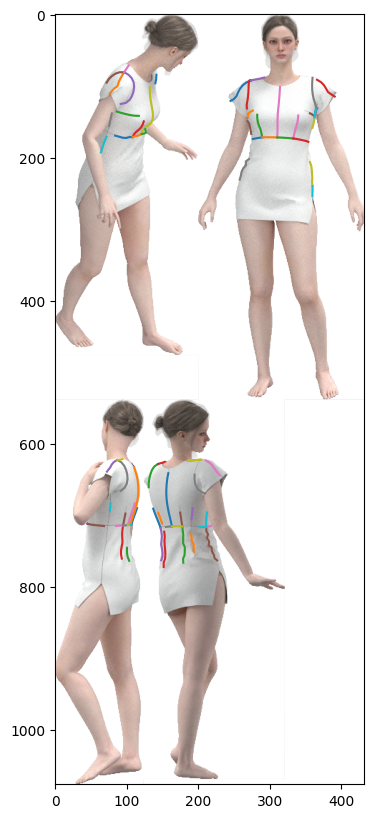

In [28]:
import os
from glob import glob
from pathlib import Path
import random


good_garment_path_list = [
    "dress_sleeveless_00F3PNYG6L__01",
    "dress_sleeveless_013LZJLUQ0__01",
    "dress_sleeveless_014TV5GC0X__01",
    "dress_sleeveless_01SGV2152F__01",
    "dress_sleeveless_02OIQPCOWU__01",
    "dress_sleeveless_02XDGBX5VN__01",
    "dress_sleeveless_03H2RT1URT__01",
    "dress_sleeveless_04HEL5MHFC__01",
    "dress_sleeveless_057TT9AFKD__01",
    "rand_52EP4QJLGQ__01__rand_S1RL0COYPS__01",
    "rand_53QD6WH0ST__01__rand_8G7N6W7FC4__01",
    "rand_53VIR9DPAS__01__rand_KIPTKV2CLQ__01",
    "rand_54KFRYT6NA__01__rand_M1T93KCG7E__01",
    "rand_58K9BF07ZA__01",
    "rand_5DY3AIHCOT__01__rand_CX5AXIQHNI__01",
    "rand_5POH1MHN4D__01__rand_LINCW20JZO__01",
    "rand_3WS8419T98__01",
    "rand_3YKPGXYGVG__01__rand_7SRESBECDF__01",
    "rand_40B81PVUQ2__01",
    "rand_479XSCBNPY__01",
    "rand_4YAT3UA7R8__01__rand_RAQBSB52SD__01",
    "rand_4YUSBEKIEW__01__rand_LW3935HGUA__01",
    "rand_6S2ZXXMSAN__01__rand_KVZGWRZW9V__01",
    "rand_6FCI14BH0F__01__rand_E2APO5A7R8__01",
    "rand_6TV00BGVH2__01",
    "rand_72PKKZ7KQO__01",
    "rand_7DVHZ4Z2QI__01",
    "rand_7JUXOOWT7M__01__rand_XTUV3QWJJK__01",
    "rand_7LIHWSA54O__01__rand_BGAZ1KPEMF__01",
    "rand_AKBI2OR18M__01__rand_RWZDY6BXLA__01",
    "rand_AKS7S180W3__01",
    "rand_ARLJF6F5A6__01__rand_DA6U9GKVUH__01",
    "rand_8BF1TGECH5__01",
    "rand_8C4GVKZS2H__01__rand_XKADFRB6OH__01",
    "rand_BP48IL1VCE__01__rand_WOQUDZY363__01",
    "rand_BW0C702IYP__01__rand_3AHQQK4O7N__01",
    "rand_9KD97VOWAM__01__rand_ZFWNJY73CK__01",
    "rand_CT9365544U__01__rand_RV8H2AT1JY__01",
    "rand_D5I1D9WP8U__01",
    "rand_DIVV7NZMOJ__01__rand_EUA743C247__01",
    "rand_DR8CO164JR__01__rand_8FV3A15E73__01",
    "rand_DWPSUB1O7Z__01__rand_OC13S0P8EP__01",
    "rand_E1JQFH83GO__01__rand_YJFTT698XZ__01",
    "rand_E72L588UKE__01",
    "rand_EJP0S4KWNM__01__rand_JS9K7VMXKE__01",
    "rand_F3OT73RNC7__01",
    "rand_GAXLYZ6NU6__01__rand_PTYS5OXS5H__01",
    "rand_G78KVPZB0W__01__rand_HF3TVP0M14__01",
    "rand_HTWC3YBD4Z__01__rand_JO6EUV7N2T__01",
    "rand_HXHHZQKHZE__01__rand_TIF3F5RMV2__01",
    "rand_I4QJZL1AX8__01__rand_RLY6VM2F0A__01",
    "rand_IITHMZRQFZ__01__rand_5T2Q7JA5DL__01",
    "rand_IQISL0OCXZ__01__rand_B5TCJ4TD31__01",
    "rand_H6SU393PMS__01",
    "rand_F06AAN66A6__01",
    "rand_ES9VPWPS5W__01",
    "rand_9FI71Q5EI8__01",
    "rand_8PVHYXQAFL__01",
    "rand_8FHNOLLBHL__01",
    "rand_8FBYI11L07__01",
    "rand_70M0P3RB7I__01",
    "rand_6NXT2QHV30__01",
    "rand_6LGVTZU5PK__01",
    "rand_4Y1S3O4ZW1__01",
    "rand_4H29SLGZ0Z__01",
    "rand_47YFEZ2030__01",
    "rand_5YJJJZ3AXP__01",
    "rand_5KLHOFNQ4U__01",
    "rand_5GFW08SG3W__01",
    "rand_5AZH65AGBK__01",
    "rand_07QS0EXUNR__01__rand_DAJZCZLFUE__01",
    "rand_13ELYX7YHC__01__rand_5169SVJN55__01",
    "rand_166KJGCYM8__01__rand_08XN9N2K6Z__01",
    "rand_1E5NSANWXW__01",
    "rand_1HVSYIRHH1__01",
    "rand_1XHYW3WQLI__01",
    "rand_245154LRY6__01",
    "rand_2WFM2BO7V4__01",
    "rand_300RQKIRSI__01",
    "rand_3GK5D4P9H0__01",
    "rand_3I08EKHVFP__01",
    "rand_3JOBG51B4X__01__rand_CT185YY7SL__01",
    "rand_3LJXT22NL0__01",
    "rand_3TAWUDGKQJ__01__rand_DCXS404V6S__01",
    "rand_3VQDDEGO8R__01",
]
good_garment_path_list = list(map(
    lambda x : os.path.join("SAMPLE_DATA", "0814", x),
    good_garment_path_list
))

sample_dir = random.choice(good_garment_path_list)


COUNT = 4
SELECTED_VIEW_IDX_LIST = random.sample(range(10), COUNT)

few_view_label = FewViewLabel.from_dir(
    sample_dir,
    selected_idx_list = SELECTED_VIEW_IDX_LIST,
)
few_view_label.combine_views()

plt.figure(figsize=(10, 10))
few_view_label.draw()

In [36]:
few_view_label.seam_annotation_list[0]['rand_6LGVTZU5PK'][6].segment_t_arr_list

[array([0.        , 0.51031663, 1.        ])]

(<Figure size 1500x2000 with 12 Axes>,
 array([[<Axes: title={'center': 'right_sleeve_b'}>,
         <Axes: title={'center': 'right_sleeve_f'}>,
         <Axes: title={'center': 'right_btorso'}>],
        [<Axes: title={'center': 'right_ftorso'}>,
         <Axes: title={'center': 'skirt_back'}>,
         <Axes: title={'center': 'skirt_front'}>],
        [<Axes: title={'center': 'left_btorso'}>,
         <Axes: title={'center': 'left_ftorso'}>,
         <Axes: title={'center': 'left_sleeve_b'}>],
        [<Axes: title={'center': 'left_sleeve_f'}>, <Axes: >, <Axes: >]],
       dtype=object))

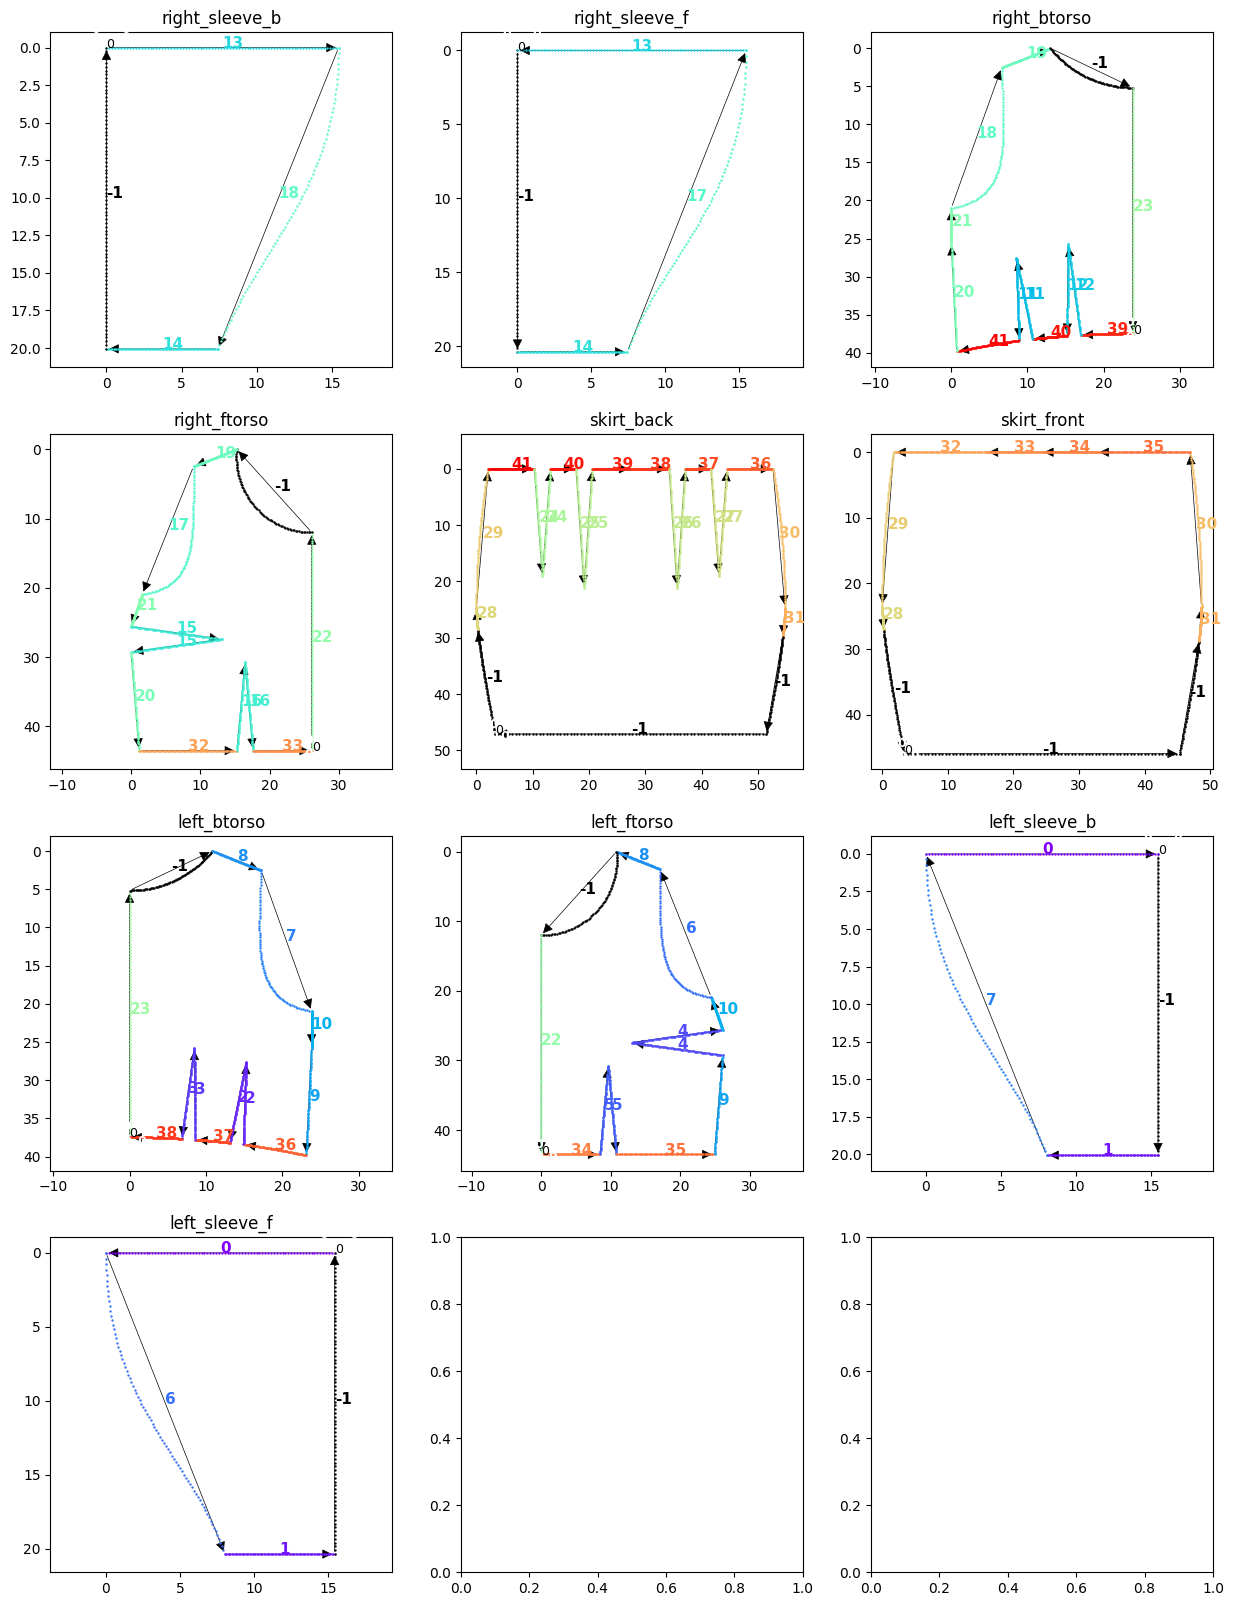

In [33]:
few_view_label.sewing_pattern_dict['rand_6LGVTZU5PK'].draw()

In [15]:
few_view_label.seam_annotation_list[0]['rand_3AHQQK4O7N'][2]

SeamLine(segment_idx_arr_list=[array([1462, 1463, 1464], dtype=int32), array([1468, 1469, 1470, 1471, 1472, 1473, 1474, 1475], dtype=int32)], segment_pos_arr_list=[array([[104.4918703 , 248.54327136],
       [103.61017005, 255.1737283 ],
       [103.35129261, 261.6978798 ]]), array([[105.19680581, 285.6574552 ],
       [105.83611807, 291.36771889],
       [105.45520213, 297.06264311],
       [105.42766386, 302.73206826],
       [105.19853773, 308.38799655],
       [104.6661142 , 314.01195657],
       [103.86670904, 319.60527069],
       [102.90403506, 325.17971503]])], segment_edge_len_arr_list=[array([0.        , 6.68882311, 6.52928559]), array([0.        , 5.74594044, 5.70764915, 5.66949203, 5.66056743,
       5.64910622, 5.65015145, 5.65695775])], segment_t_arr_list=[array([0.        , 0.50603481, 1.        ]), array([0.        , 0.14458883, 0.28821411, 0.43087922, 0.57331975,
       0.71547187, 0.8576503 , 1.        ])], segment_u_arr_list=[array([0.        , 0.50604775, 1.        

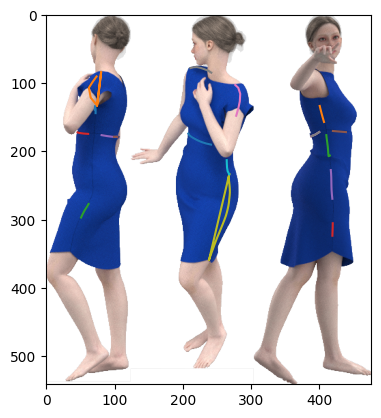

In [302]:
img_path_list = list(map(
    lambda x : x.replace(".pkl", ".png"),
    annot_path_list
))

SELECTED_VIEW_IDX_LIST = [0, 1]
COUNT = 3
SELECTED_VIEW_IDX_LIST = random.sample(range(len(img_path_list)), COUNT)


few_view_label = FewViewLabel.from_file_path(
    [img_path_list[i] for i in SELECTED_VIEW_IDX_LIST],
    [annot_path_list[i] for i in SELECTED_VIEW_IDX_LIST],
)
few_view_label.combine_views()

few_view_label.draw()

In [9]:
IDX = 9

garment_path = garment_path_list[IDX]

seam_annotation_path_list = sorted(glob(os.path.join(garment_path, "*.pkl")))

print(seam_annotation_path_list)

seam_annotation_list = list(map(
    lambda x : pickle.load(open(x, "rb")),
    seam_annotation_path_list
))
image_list = list(map(
    lambda x : Image.open(x.replace("_seam_line.pkl", ".png")),
    seam_annotation_path_list
))

SPEC_PATH = list(filter(
    lambda x : "specification" in x,
    glob(
        os.path.join(
            os.path.dirname(seam_annotation_path_list[0]), "*.json"
        )
    )
))[0]

pattern = pyg.pattern.wrappers.VisPattern(SPEC_PATH)

panel_svg_path_dict = {
    panel_name : pattern._draw_a_panel(
        panel_name, apply_transform=False, fill=True
    )
    for panel_name in pattern.panel_order()
}
stitch_dict = {
    i : v for i, v in enumerate(pattern.pattern['stitches'])
}

sewing_pattern = SewingPattern(panel_svg_path_dict, stitch_dict)

sewing_pattern.draw(
    plot_panel_name = False,
    # plot_stitch_name = False
)

['SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_10__Dramatic.pkl', 'SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_1__Dynamic_2.pkl', 'SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_2__Dynamic.pkl', 'SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_3__FV2_07.pkl', 'SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_4__FV2_05.pkl', 'SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_5__Dramatic.pkl', 'SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_6__Dynamic_2.pkl', 'SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_7__Dramatic.pkl', 'SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_8__FV2_05.pkl', 'SAMPLE_DATA/0814/dress_sleeveless_048BBSET3Z__01/Custom_View_9__FV2_05.pkl']


NameError: name 'pickle' is not defined

In [14]:
# 수정 시 대칭으로 하도록 함.



dict_keys(['pant_b_r', 'pant_f_r', 'pant_b_l', 'pant_f_l'])

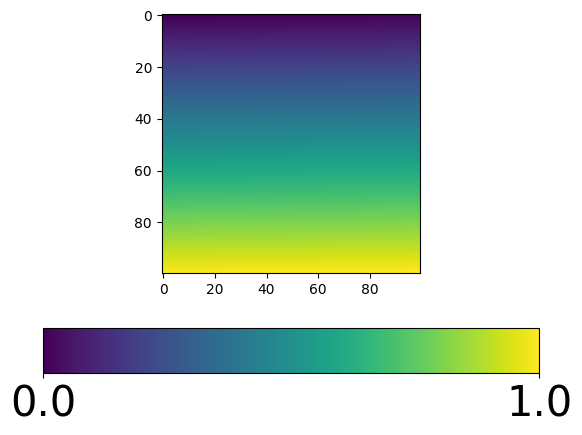

In [33]:
import matplotlib.pyplot as plt
import numpy as np


plt.imshow(np.linspace(0, 1, 10000).reshape(100, 100))
cbar = plt.colorbar(orientation='horizontal', aspect=11)  # Increased aspect ratio makes colorbar taller
cbar.set_ticks([0.0, 1.])
cbar.ax.tick_params(labelsize=30)  # Set font size of colorbar ticks to 14
cbar.ax.set_xticklabels(['{:.1f}'.format(x) for x in cbar.get_ticks()])  # Format as float
plt.show()